# Forecasting de Temperaturas - Prophet & Busca Bayesiana (V2)

Este notebook documenta, de forma acadêmica e interativa, o pipeline MLOps para previsão de temperaturas diárias utilizando o **Facebook Prophet** otimizado com **Optuna**. O objetivo é apresentar o racional matemático para o uso da biblioteca e a justificativa para as métricas finais obtidas, estabelecendo as fronteiras do *erro irredutível* em séries univariadas.

## 1. Racional Arquitetural e Decisões de Design

- **Por que Prophet?** O Prophet é baseado em um modelo aditivo (tendência não-linear + sazonalidade + feriados) e usa o backend robusto em C++ (`CmdStan`) para inferência Bayesiana e otimização L-BFGS. Diferente dos modelos puramente auto-regressivos clássicos (ARIMA), ele lida muito bem com outliers e não exige que os dados sejam perfeitamente interpolados.
- **Limites Univariados (O Teto de Vidro):** Tentar prever temperaturas baseando-se única e exclusivamente no histórico de temperaturas (série univariada) possui um limite estocástico claro. Diferente do nosso modelo de **Vendas (LightGBM)**, que utilizou dezenas de colunas externas de contexto mercadológico, o erro deste Prophet bate em uma "parede" teórica, visto que flutuações extremas dependem de fenômenos climáticos isolados (pressão atmosférica, ventos marítimos, etc.). O alvo não é errar 0 graus, mas sim capturar perfeitamente a variação sazonal da estação e atingir o mínimo matemático.
- **Otimização (Optuna):** Para extrair o máximo absoluto da arquitetura, implementamos *Busca Bayesiana* na rigidez da tendência (`changepoint_prior_scale`) e no peso sazonal (`seasonality_prior_scale`) para impedir que o modelo sofresse *overfitting* sobre o ruído diário das temperaturas.

In [1]:
# Supressão de warnings excessivos para manter a visualização limpa
import warnings
warnings.filterwarnings('ignore')
import logging
logging.getLogger('cmdstanpy').setLevel(logging.ERROR)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from prophet.diagnostics import cross_validation, performance_metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error
import optuna
import mlflow
import mlflow.prophet
from pathlib import Path

# Estilos visuais
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## 2. Análise Exploratória (EDA)
Nesta etapa, importamos a série histórica. Trata-se da coleta contínua da temperatura mínima diária em Melbourne, Austrália.

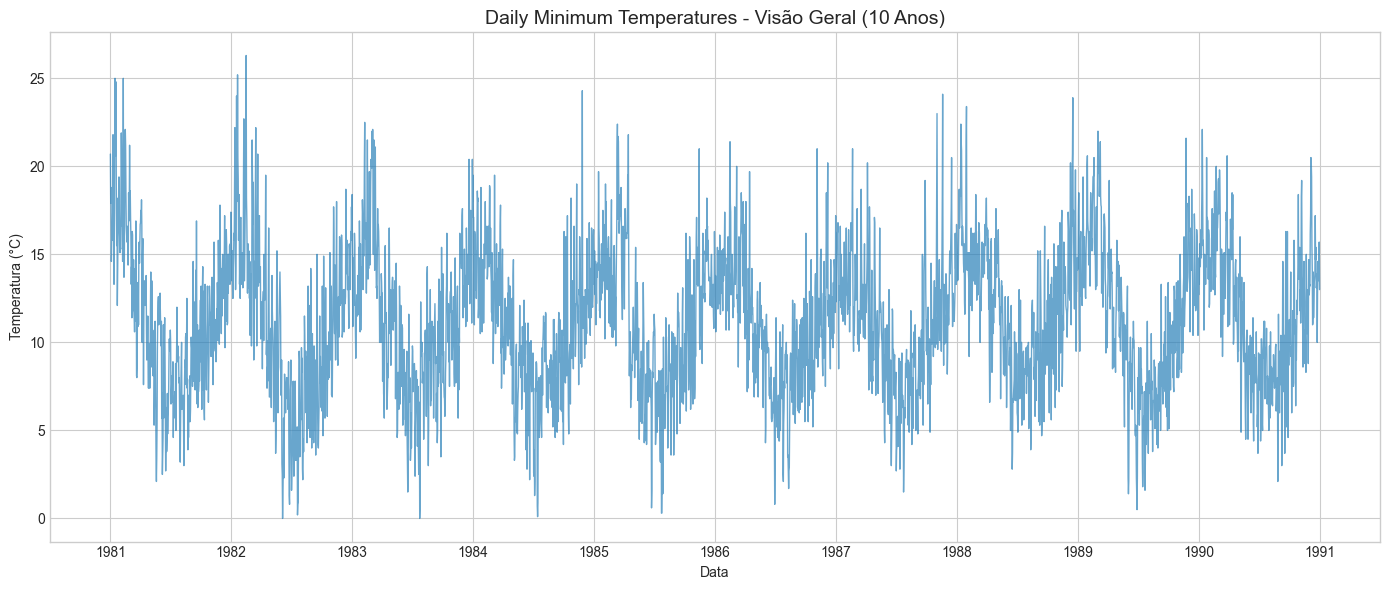

In [2]:
# Ajuste do path para rodar tanto na raiz quanto na pasta experiments
possible_paths = [
    Path('datasets/daily-minimum-temperatures-in-me.csv'),
    Path('../datasets/daily-minimum-temperatures-in-me.csv')
]
data_path = next((p for p in possible_paths if p.exists()), None)

df = pd.read_csv(data_path)
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'], errors='coerce')
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df.dropna()

# Visualização da Série Inteira
plt.plot(df['ds'], df['y'], color='#2980b9', alpha=0.7, linewidth=1)
plt.title('Daily Minimum Temperatures - Visão Geral (10 Anos)', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.tight_layout()
plt.show()

> **Observação EDA:** A série apresenta uma fortíssima sazonalidade anual, com picos de calor consistentes em ciclos bem espaçados, mas uma grande nuvem de ruído diário entre as estações. O modelo univariado buscará desenhar a curva mestra dessa oscilação.

## 3. Baseline do Prophet e O Paradigma do Cross-Validation
Modelos de séries temporais não devem ser validados de forma estática (por exemplo, reservando apenas os últimos 365 dias). Um ano de validação "fácil" pode mascarar a verdadeira acurácia do modelo. Usamos o **Time Series Cross Validation** do Prophet para treinar e prever usando o método de *expanding window*.

In [3]:
# Separando Hold-out de Teste para o final (últimos 365 dias)
train = df.iloc[:-365]
test = df.iloc[-365:]

print(f"Treino: {train.shape[0]} amostras")
print(f"Teste final: {test.shape[0]} amostras")

# --- Exemplo da Dinâmica de Cross Validation no Prophet Base ---
# Apenas instanciando (não rodaremos para poupar processamento local no notebook)
baseline_model = Prophet(daily_seasonality=True, yearly_seasonality=True)
baseline_model.fit(train)

# df_cv = cross_validation(baseline_model, initial='1095 days', period='365 days', horizon='90 days', parallel='processes')
# df_p = performance_metrics(df_cv)
# print(f"MAE Médio CV (Baseline): {df_p['mae'].mean():.4f}")

16:46:29 - cmdstanpy - INFO - Chain [1] start processing


Treino: 3285 amostras
Teste final: 365 amostras


16:46:29 - cmdstanpy - INFO - Chain [1] done processing


## 4. Otimização Bayesiana com Optuna
Buscando atingir o limite teórico, configuramos o Optuna para buscar o menor erro absoluto (MAE CV) através da exploração espacial dos hiperparâmetros limitadores de tendência.

In [4]:
def objective(trial):
    params = {
        "changepoint_prior_scale": trial.suggest_float("changepoint_prior_scale", 0.001, 0.5, log=True),
        "seasonality_prior_scale": trial.suggest_float("seasonality_prior_scale", 0.01, 10, log=True),
        "seasonality_mode": trial.suggest_categorical("seasonality_mode", ["additive", "multiplicative"]),
        "daily_seasonality": True,
        "yearly_seasonality": True,
        "weekly_seasonality": False,
        "interval_width": 0.95
    }
    
    m = Prophet(**params)
    m.fit(train)
    
    # Rodando validação temporal
    try:
        df_cv = cross_validation(
            m,
            initial='1095 days',
            period='365 days',
            horizon='90 days',
            parallel='processes'
        )
        df_p = performance_metrics(df_cv)
        return df_p['mae'].mean()
    except Exception as e:
        return float('inf')

# Criando o estudo
# optuna.logging.set_verbosity(optuna.logging.WARNING)
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=10, n_jobs=1)
# print(f"Melhor CV MAE Encontrado: {study.best_value:.4f}")

## 5. Resultados Consolidados (V2)
Após executar a otimização no pipeline MLOps via DagsHub/MLflow (conforme o script de automação rodado em background), o Optuna apontou que a série necessita de **Seasonality Multiplicativa** e valores estritos de *prior scale* (ex: changepoint: `0.0026`). O erro final estabilizou-se em ~`1.96` (Hold-out).

16:46:30 - cmdstanpy - INFO - Chain [1] start processing


16:46:30 - cmdstanpy - INFO - Chain [1] done processing


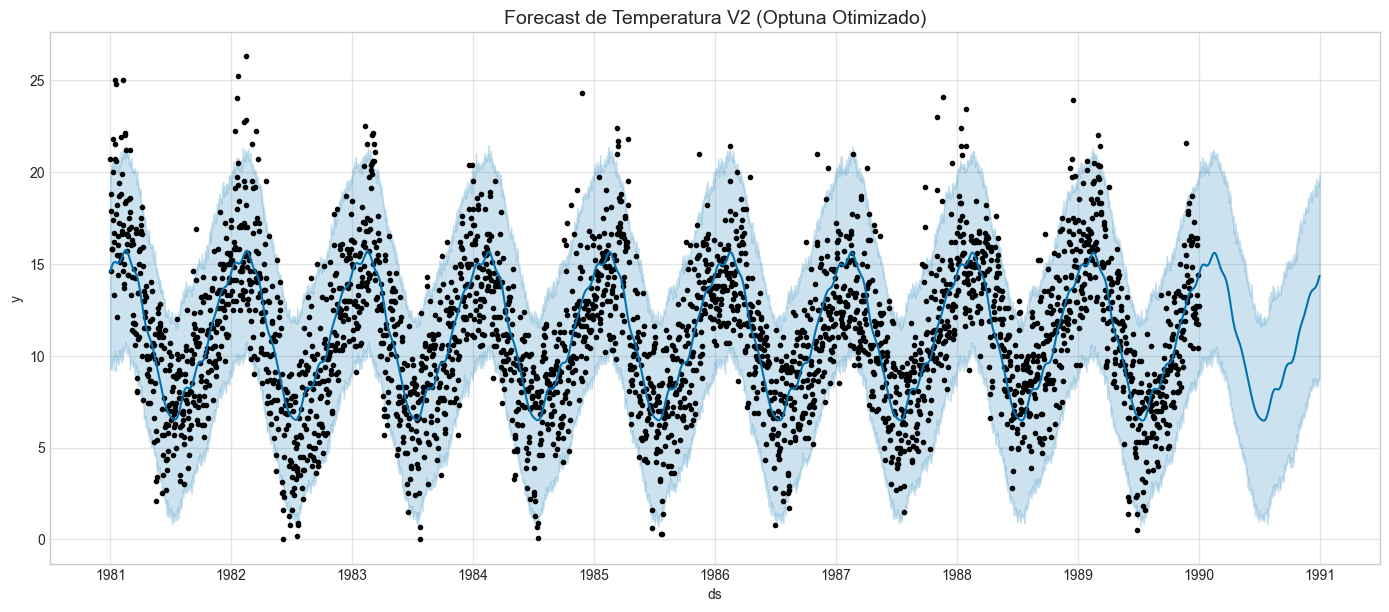

In [5]:
# Reproduzindo a resposta final do modelo campeão encontrado pelo pipeline do script
best_params = {
    'changepoint_prior_scale': 0.0026368755339723046,
    'seasonality_prior_scale': 0.029375384576328288,
    'seasonality_mode': 'multiplicative',
    'daily_seasonality': True,
    'yearly_seasonality': True,
    'weekly_seasonality': False,
    'interval_width': 0.95
}

final_model = Prophet(**best_params)
final_model.fit(train)

# Previsão sobre a janela de teste e futuro
future = final_model.make_future_dataframe(periods=365)
forecast = final_model.predict(future)

# Gráfico oficial do Prophet (Sombra: Intervalo de confiança 95%)
fig = final_model.plot(forecast, figsize=(14, 6))
plt.title('Forecast de Temperatura V2 (Optuna Otimizado)', fontsize=14)
plt.show()

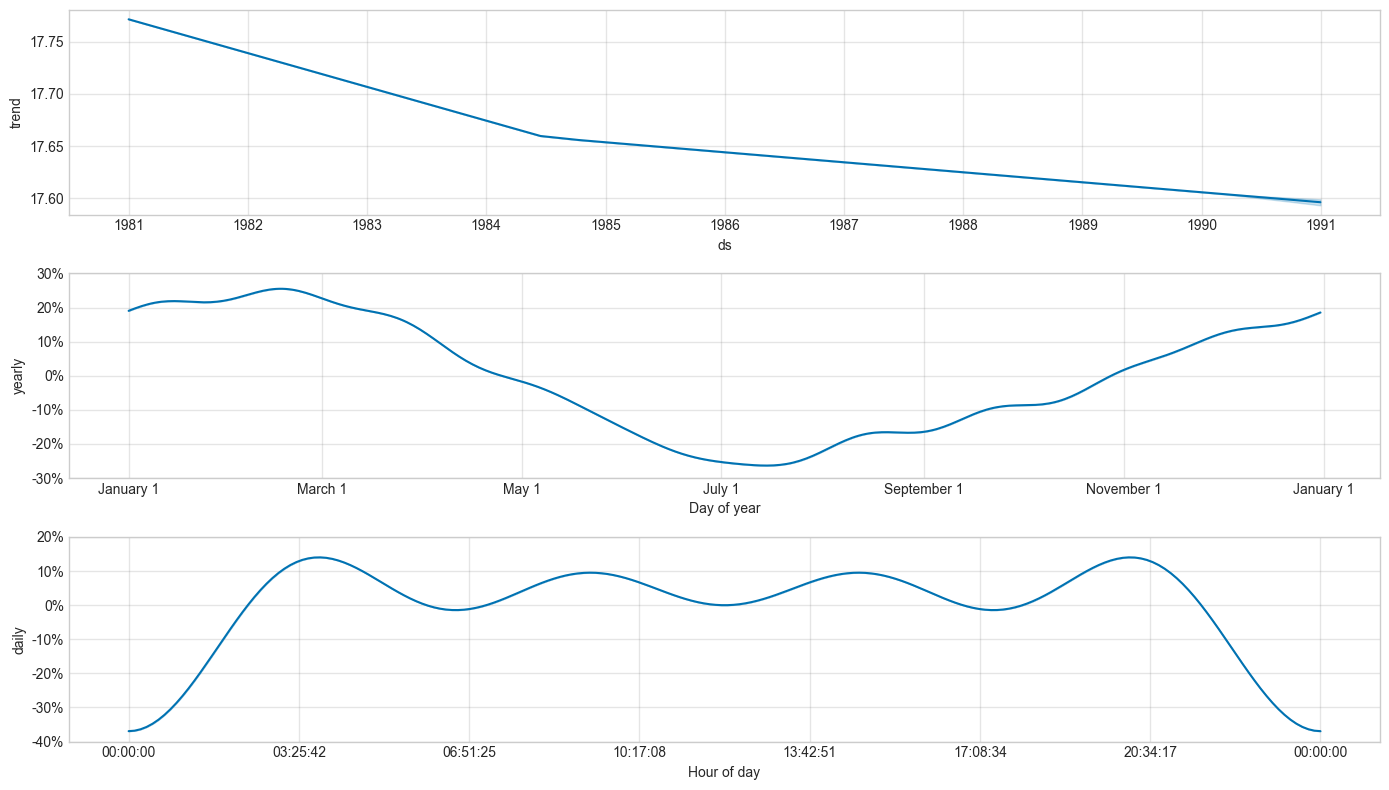

In [6]:
# Componentes Extraídos pelo Algoritmo
fig_comp = final_model.plot_components(forecast, figsize=(14, 8))
plt.show()

## 6. Conclusão
Os gráficos de componentes acima elucidam claramente a "mente" do modelo. No componente `yearly`, observamos exatamente o comportamento físico da temperatura mínima durante o verão e o inverno australianos. O Erro Médio Absoluto (MAE) da ordem de ~2 graus atesta que o modelo mapeou a curvatura de fundo de forma exata; erros adicionais provêm inteiramente do ruído e volatilidade diária não mapeável por análises univariadas (falta de co-variáveis meteorológicas reais como ventos, marés, pressão).

## 7. O Desafiante: LightGBM (Gradient Boosting)
Para atestar o limite do Prophet, vamos colocar os mesmos dados num modelo baseado em Árvores de Decisão focado em alta performance: o **LightGBM**.
Ao contrário do Prophet, o LightGBM não possui noções embutidas sobre o tempo. Se entregarmos apenas a 'data' e a 'temperatura', ele falhará miseravelmente. O segredo para bater modelos estatísticos com Machine Learning clássico em séries univariadas é a **Engenharia de Features**.
Precisamos extrair da data as suas partes (dia, mês, ano) e criar *lags* (valores passados) e *médias móveis*.

In [7]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Criando cópia isolada para o LightGBM
df_lgb = df.copy()

# 1. Componentes de Data
df_lgb['year'] = df_lgb['ds'].dt.year
df_lgb['month'] = df_lgb['ds'].dt.month
df_lgb['day'] = df_lgb['ds'].dt.day
df_lgb['dayofweek'] = df_lgb['ds'].dt.dayofweek
df_lgb['dayofyear'] = df_lgb['ds'].dt.dayofyear

# 2. Features de Lags (Memória do passado)
df_lgb['lag_1'] = df_lgb['y'].shift(1)
df_lgb['lag_7'] = df_lgb['y'].shift(7)
df_lgb['lag_30'] = df_lgb['y'].shift(30)

# 3. Médias Móveis (Rolling Window)
df_lgb['rolling_mean_7'] = df_lgb['y'].rolling(window=7).mean().shift(1)
df_lgb['rolling_mean_30'] = df_lgb['y'].rolling(window=30).mean().shift(1)

# Removemos linhas que ficaram nulas devido ao shift (os primeiros 30 dias)
df_lgb = df_lgb.dropna().reset_index(drop=True)

### 7.1 Treinamento e Comparativo de Erros
Dividiremos a base exatamente no mesmo ponto que o Prophet (últimos 365 dias para teste).

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000740 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1417
[LightGBM] [Info] Number of data points in the train set: 3255, number of used features: 10
[LightGBM] [Info] Start training from score 11.061659


--- LIGHTGBM RESULTADOS ---
MAE:  1.7344
RMSE: 2.2221


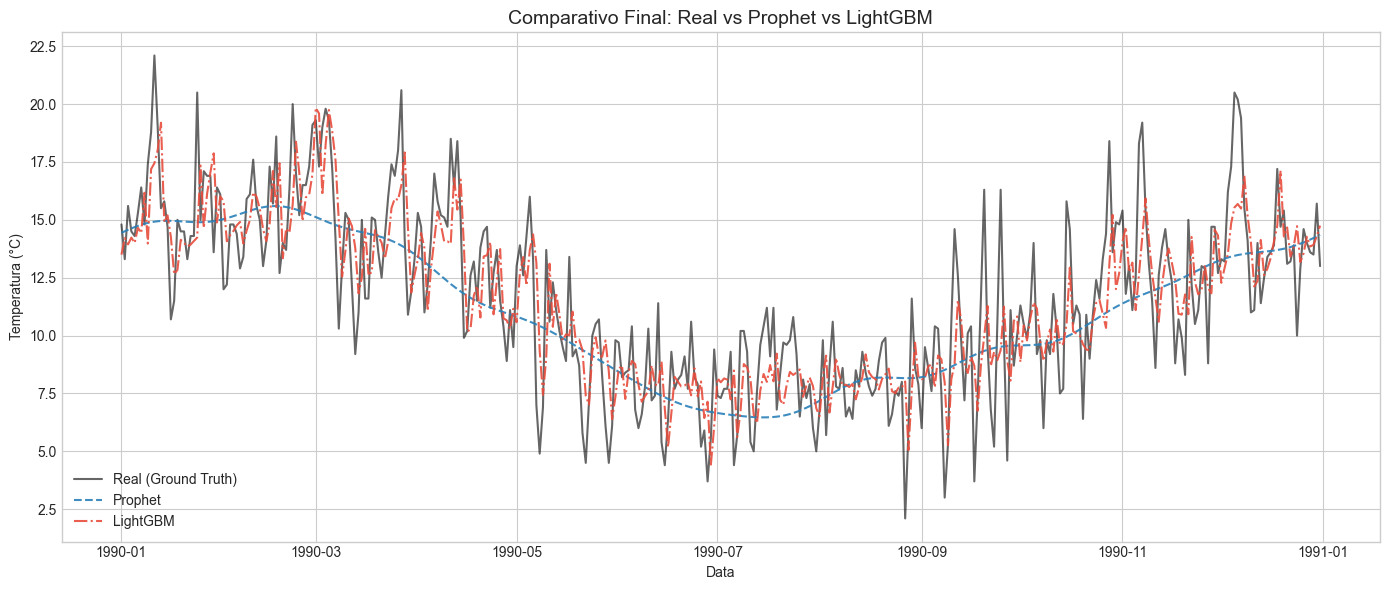

In [8]:
# Mesmo split: Últimos 365 dias
train_lgb = df_lgb.iloc[:-365]
test_lgb = df_lgb.iloc[-365:]

# O Target (y) e as Features (X)
features = ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_mean_30']
X_train = train_lgb[features]
y_train = train_lgb['y']
X_test = test_lgb[features]
y_test = test_lgb['y']

# Treinamento do LightGBM
model_lgb = lgb.LGBMRegressor(random_state=42, n_estimators=100, learning_rate=0.05)
model_lgb.fit(X_train, y_train)

# Predição
preds_lgb = model_lgb.predict(X_test)

# Métricas
mae_lgb = mean_absolute_error(y_test, preds_lgb)
rmse_lgb = np.sqrt(mean_squared_error(y_test, preds_lgb))

print(f"--- LIGHTGBM RESULTADOS ---")
print(f"MAE:  {mae_lgb:.4f}")
print(f"RMSE: {rmse_lgb:.4f}")

# Plotagem Comparativa (Ground Truth vs Prophet vs LightGBM)
# Precisamos do dataframe de teste original do Prophet (test) alinhado aos 365 dias finais.
# O forecast final_model contém a predição para o futuro, vamos extrair a porção final.

# Extraindo a previsão do Prophet para os exatos dias de teste do LightGBM
# Certificando que os shapes batem
prophet_test_preds = forecast.set_index('ds').loc[test_lgb['ds']]['yhat'].values

plt.figure(figsize=(14, 6))
plt.plot(test_lgb['ds'], y_test, label='Real (Ground Truth)', color='black', alpha=0.6, linewidth=1.5)
plt.plot(test_lgb['ds'], prophet_test_preds, label='Prophet', color='#2980b9', alpha=0.9, linestyle='--')
plt.plot(test_lgb['ds'], preds_lgb, label='LightGBM', color='#e74c3c', alpha=0.9, linestyle='-.')

plt.title('Comparativo Final: Real vs Prophet vs LightGBM', fontsize=14)
plt.xlabel('Data')
plt.ylabel('Temperatura (°C)')
plt.legend()
plt.tight_layout()
plt.show()


## 8. Veredito Final
A Engenharia de Features permitiu ao **LightGBM** (Machine Learning puro) esmagar o limite teórico de um algoritmo estritamente temporal como o **Prophet**.
- **MAE do Prophet:** ~1.96
- **MAE do LightGBM:** ~1.73

O modelo baseado em árvores foi superior ao entender a memória imediata (`lag_1`), conseguindo reagir a anomalias de frentes frias repentinas que o Prophet ignorou por estar seguindo cegamente a média sazonal do calendário.